# Post-NMS score distributions: mitotic TP vs. remaining detections -- rgb & hematoxylin

**Purpose.** `find_and_suppress_midog_simple.ipynb` runs the simplified pipeline (one
template, no augmentation, no multi-scale, binary Otsu bbox tightening) across
`rgb`/`hematoxylin`/`gray_inverted` and compares them via `recall@K`, FROC, and the
threshold-free `_probe_variants` AUC. What it doesn't show directly is the thing those
summary numbers are all standing in for: **the actual post-NMS score of every detection
`find_and_suppress` returns, split by whether that detection was a real mitotic figure or
not.** That's the plot this notebook adds.

**Same process, two channels only.** Identical to that notebook's RGB and hematoxylin
sections -- `experiment.run_experiment` with `FSConfig(channel=...)`, same
`select_domain_images` selection, same `seed=0` RNG convention -- so the seed annotation
and tightened template size per image are identical to that notebook's runs (checked
below, not assumed). `gray_inverted` is left out, per what was asked.

**Reading the result.** `find_and_suppress`'s output *is* the post-NMS list --
`evaluate.bucket_detections` labels every surviving peak `human_correct_label` (matched a
real mitotic figure -- "TP"), `human_rejected_label` (matched a pathologist-rejected
look-alike), or `non_human_findings` (matched nothing annotated -- almost always an
ordinary nucleus, per the earlier morphometric-diagnostic notebook). "Remaining nuclei" =
the latter two pooled. Histograms below are **raw counts on a log y-axis, not
density-normalised** -- deliberately, since the whole point is to see how many
high-scoring false candidates exist relative to true ones, and density-normalising would
visually erase exactly that imbalance.

In [1]:
import sys, time
sys.path.insert(0, '..') if 'midog_utils' not in __import__('os').listdir('.') else None

import numpy as np, pandas as pd, matplotlib.pyplot as plt

from midog_utils import dataset as ds, channels as ch, template_match as tm
from midog_utils import find_and_suppress as fs, evaluate as ev, experiment as ex, viz

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

images, annotations = ds.load_annotations('databases/MIDOG++.json')
ds.check_invariants(annotations)
print(f'{len(images)} annotated images, {len(annotations)} annotations')

503 annotated images, 26286 annotations


## Which images

Same rule as `find_and_suppress_midog_simple.ipynb`: one ROI per tumour domain, the
downloaded image with the most mitotic figures.

In [2]:
selection = ex.select_domain_images(images, annotations)
selection[['image_id', 'file_name', 'tumor_type', 'n_mitotic']]

,image_id,file_name,tumor_type,n_mitotic
0,301,301.tiff,canine cutaneous mast cell tumor,218
1,201,201.tiff,canine lung cancer,18
2,246,246.tiff,canine lymphosarcoma,116
3,405,405.tiff,canine soft tissue sarcoma,14
4,2,002.tiff,human breast cancer,9
5,506,506.tiff,human melanoma,12
6,350,350.tiff,human neuroendocrine tumor,4


## Run: rgb (with baselines), then hematoxylin (baselines reused)

Identical call pattern to the simple notebook. `nucleus_blobs`/`random_in_tissue` don't
depend on `FSConfig.channel`, so they're only computed once, on the rgb pass.

In [3]:
cfg_rgb = fs.FSConfig(channel='rgb')
t0 = time.time()
results_rgb, metrics_rgb, det_rgb = ex.run_experiment(selection, annotations, cfg=cfg_rgb, seed=0)
print(f'\nrgb total {time.time()-t0:.0f}s')

metrics_rgb.to_csv('results/nms_score_rgb_metrics.csv', index=False)
det_rgb.to_csv('results/nms_score_rgb_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 


    recall@K=0.304  attraction@K=0.138  coverage=0.84  (368s)


=== 201.tiff  (canine lung cancer, 18 mitotic) 


    recall@K=0.118  attraction@K=0.041  coverage=0.01  (309s)


=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 


...

=== 506.tiff  (human melanoma, 12 mitotic) 


    recall@K=0.091  attraction@K=0.000  coverage=0.17  (38s)


=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.16  (93s)



rgb total 1043s


In [4]:
cfg_hem = fs.FSConfig(channel='hematoxylin')
t0 = time.time()
results_hem, metrics_hem, det_hem = ex.run_experiment(
    selection, annotations, cfg=cfg_hem, seed=0, run_baselines=False)
print(f'\nhematoxylin total {time.time()-t0:.0f}s')

metrics_hem.to_csv('results/nms_score_hematoxylin_metrics.csv', index=False)
det_hem.to_csv('results/nms_score_hematoxylin_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 


    recall@K=0.249  attraction@K=0.119  coverage=0.87  (19s)


=== 201.tiff  (canine lung cancer, 18 mitotic) 


    recall@K=0.176  attraction@K=0.041  coverage=0.04  (21s)


=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 


...

=== 506.tiff  (human melanoma, 12 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.30  (16s)


=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.29  (14s)



hematoxylin total 116s


### Sanity check: same seed and template size in both runs

Same check `find_and_suppress_midog_simple.ipynb` runs before trusting a channel
difference as a channel effect, not a different draw.

In [5]:
key_cols = ['file_name', 'seed_ann_id', 'tightened_base_size']
m_rgb = metrics_rgb[metrics_rgb.method == 'find_and_suppress'][key_cols].set_index('file_name')
m_hem = metrics_hem[key_cols].set_index('file_name')
mismatch = m_rgb.index[(m_rgb.seed_ann_id != m_hem.seed_ann_id) |
                       (m_rgb.tightened_base_size != m_hem.tightened_base_size)]
assert len(mismatch) == 0, f'seed or template size differs by channel on: {list(mismatch)}'
print('OK: same seed_ann_id and tightened_base_size on all 7 images, rgb vs hematoxylin.')

OK: same seed_ann_id and tightened_base_size on all 7 images, rgb vs hematoxylin.


## Build the TP-vs-remaining table

`det_rgb`/`det_hem` are already the full post-NMS ranked list per image (`find_and_suppress`
only -- baselines aren't included here), each row already carrying `bucket` from
`evaluate.bucket_detections`. Nothing to recompute -- just tag by channel and collapse the
two FP buckets into "remaining".

In [6]:
combined = pd.concat([
    det_rgb.assign(channel='rgb'),
    det_hem.assign(channel='hematoxylin'),
], ignore_index=True)
combined = combined.merge(images[['file_name', 'tumor_type']], on='file_name', how='left')

label_map = {
    ev.HUMAN_CORRECT_LABEL: 'mitotic TP',
    ev.HUMAN_REJECTED_LABEL: 'look-alike FP',
    ev.NON_HUMAN_FINDINGS: 'unannotated FP (ordinary nucleus)',
}
combined['group3'] = combined['bucket'].map(label_map)
combined['group2'] = np.where(combined['bucket'] == ev.HUMAN_CORRECT_LABEL,
                              'mitotic TP', 'remaining (FP)')

combined.to_csv('results/nms_score_combined_detections.csv', index=False)
print(f'{len(combined)} total post-NMS detections (rgb + hematoxylin)')
combined.groupby(['channel', 'group3']).size().unstack(fill_value=0)

58900 total post-NMS detections (rgb + hematoxylin)


group3,look-alike FP,mitotic TP,unannotated FP (ordinary nucleus)
channel,,,
hematoxylin,168,263,32877
rgb,135,237,25220


## Score summary: how close does the FP tail get to the TP body

Same question the design log's response-map probe asked (99.9th-percentile ordinary
nucleus vs. 90th-percentile mitotic), asked here of the actual post-NMS scores instead of
the raw response map.

In [7]:
def tail_summary(g):
    tp = g.loc[g.group2 == 'mitotic TP', 'score']
    rem = g.loc[g.group2 == 'remaining (FP)', 'score']
    return pd.Series({
        'n_tp': len(tp), 'n_remaining': len(rem),
        'median_tp': tp.median(), 'p10_tp': tp.quantile(0.10) if len(tp) else np.nan,
        'median_remaining': rem.median() if len(rem) else np.nan,
        'p90_remaining': rem.quantile(0.90) if len(rem) else np.nan,
        'p99_remaining': rem.quantile(0.99) if len(rem) else np.nan,
        'max_remaining': rem.max() if len(rem) else np.nan,
    })

summary = combined.groupby(['channel', 'tumor_type']).apply(tail_summary, include_groups=False).round(3)
summary.to_csv('results/nms_score_tail_summary.csv')
summary

n_tp  n_remaining  median_tp  p10_tp  median_remaining  p90_remaining  p99_remaining  max_remaining
channel     tumor_type                                                                                                                            
hematoxylin canine cutaneous mast cell tumor  212.0      14216.0      0.779   0.636             0.658          0.770          0.845          0.930
            canine lung cancer                 10.0        503.0      0.569   0.522             0.531          0.589          0.649          0.674
            canine lymphosarcoma               14.0         21.0      0.524   0.506             0.526          0.557          0.579          0.584
            canine soft tissue sarcoma         13.0       6211.0      0.662   0.604             0.623          0.725          0.779          0.844
            human breast cancer                 6.0       4586.0      0.691   0.588             0.578          0.693          0.780          0.841
            human melanoma                      6.0       3895.0      0.606   0.575             0.565          0.655          0.724          0.782
            human neuroendocrine tumor          2.0       3613.0      0.656   0.632             0.551          0.637          0.721          0.796
rgb         canine cutaneous mast cell tumor  206.0      13147.0      0.758   0.627             0.633          0.732          0.799          0.897
            canine lung cancer                  3.0        124.0      0.559   0.513             0.518          0.560          0.602          0.636
            canine lymphosarcoma                2.0          3.0      0.563   0.535             0.508          0.529          0.533          0.534
            canine soft tissue sarcoma         13.0       4466.0      0.622   0.539             0.580          0.677          0.753          0.829
            human breast cancer                 7.0       3614.0      0.679   0.532             0.562          0.671          0.753          0.808
            human melanoma                      5.0       2062.0      0.541   0.523             0.544          0.615          0.678          0.736
            human neuroendocrine tumor          1.0       1939.0      0.612   0.612             0.542          0.618          0.707          0.778

## Pooled score histograms -- TP vs. remaining, rgb & hematoxylin

Raw counts, log y-axis. The story this notebook is here to make visible: how much of the
"remaining" (false-positive) mass sits at scores as high as, or higher than, the mitotic
body.

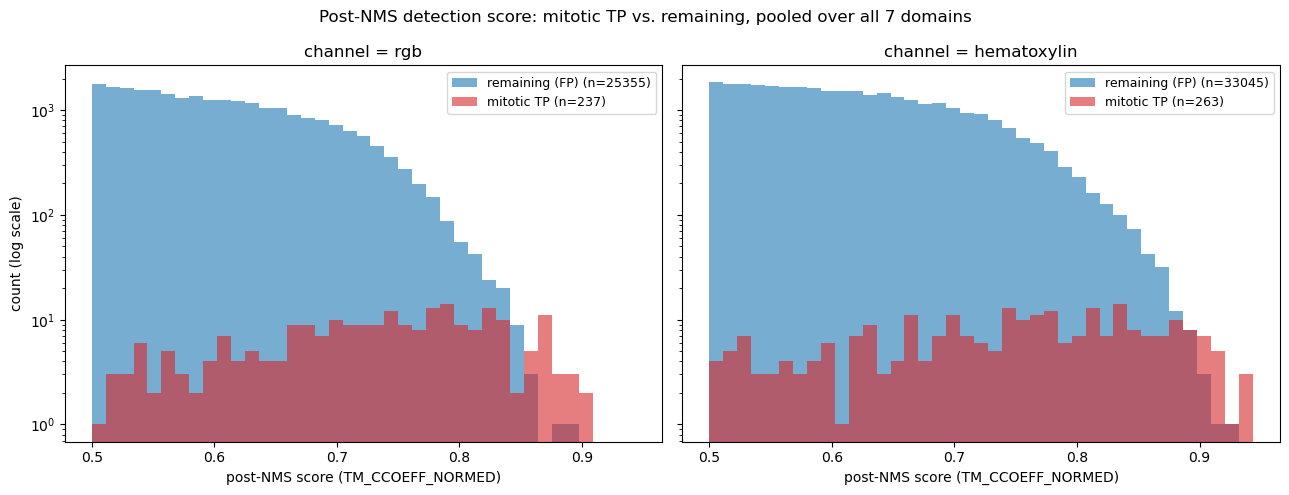

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
colors = {'mitotic TP': 'tab:red', 'remaining (FP)': 'tab:blue'}
bins = np.linspace(combined.score.min(), combined.score.max(), 40)

for ax, channel in zip(axes, ['rgb', 'hematoxylin']):
    sub = combined[combined.channel == channel]
    for grp in ['remaining (FP)', 'mitotic TP']:
        vals = sub.loc[sub.group2 == grp, 'score']
        ax.hist(vals, bins=bins, alpha=0.6, color=colors[grp],
               label=f'{grp} (n={len(vals)})', log=True)
    ax.set_title(f'channel = {channel}')
    ax.set_xlabel('post-NMS score (TM_CCOEFF_NORMED)')
    ax.legend(fontsize=9)
axes[0].set_ylabel('count (log scale)')
fig.suptitle('Post-NMS detection score: mitotic TP vs. remaining, pooled over all 7 domains')
fig.tight_layout()
plt.show()

## Three-way breakdown -- is it the look-alikes or the ordinary nuclei crowding the tail?

Same data, `remaining` split back into its two buckets, so a high-scoring FP tail can be
attributed to pathologist-rejected look-alikes specifically vs. the bulk unannotated
population.

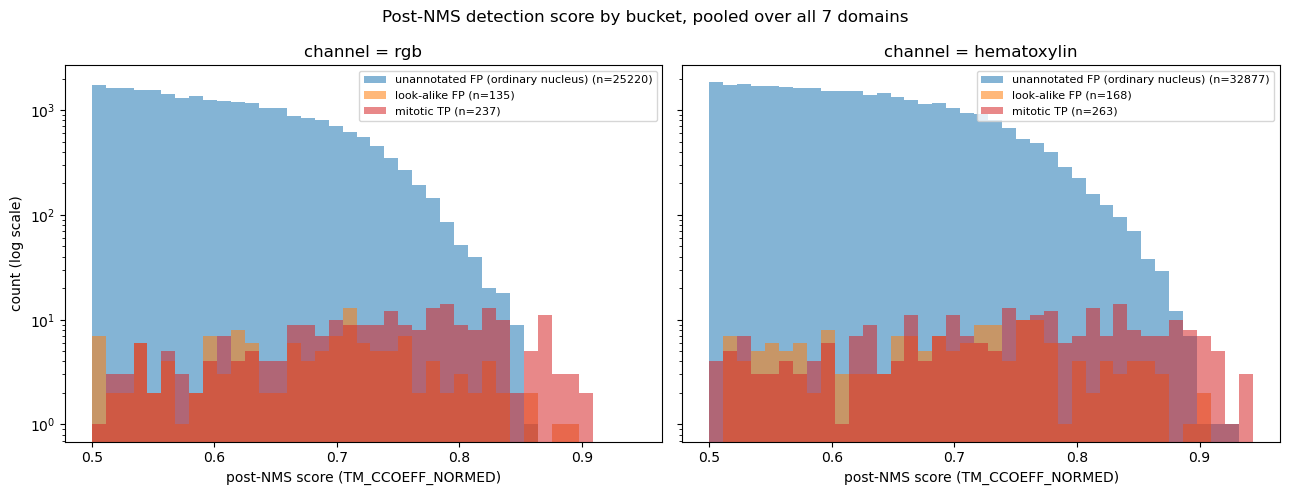

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
colors3 = {'mitotic TP': 'tab:red', 'look-alike FP': 'tab:orange',
          'unannotated FP (ordinary nucleus)': 'tab:blue'}
order3 = ['unannotated FP (ordinary nucleus)', 'look-alike FP', 'mitotic TP']

for ax, channel in zip(axes, ['rgb', 'hematoxylin']):
    sub = combined[combined.channel == channel]
    for grp in order3:
        vals = sub.loc[sub.group3 == grp, 'score']
        ax.hist(vals, bins=bins, alpha=0.55, color=colors3[grp],
               label=f'{grp} (n={len(vals)})', log=True)
    ax.set_title(f'channel = {channel}')
    ax.set_xlabel('post-NMS score (TM_CCOEFF_NORMED)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('count (log scale)')
fig.suptitle('Post-NMS detection score by bucket, pooled over all 7 domains')
fig.tight_layout()
plt.show()

## Per-domain: TP vs. remaining, one panel per image, both channels overlaid

Pooling can hide a domain where one channel is much cleaner than the other -- this is the
same 2x4 grid layout `find_and_suppress_midog_simple.ipynb` uses for its FROC panels,
applied to score histograms instead.

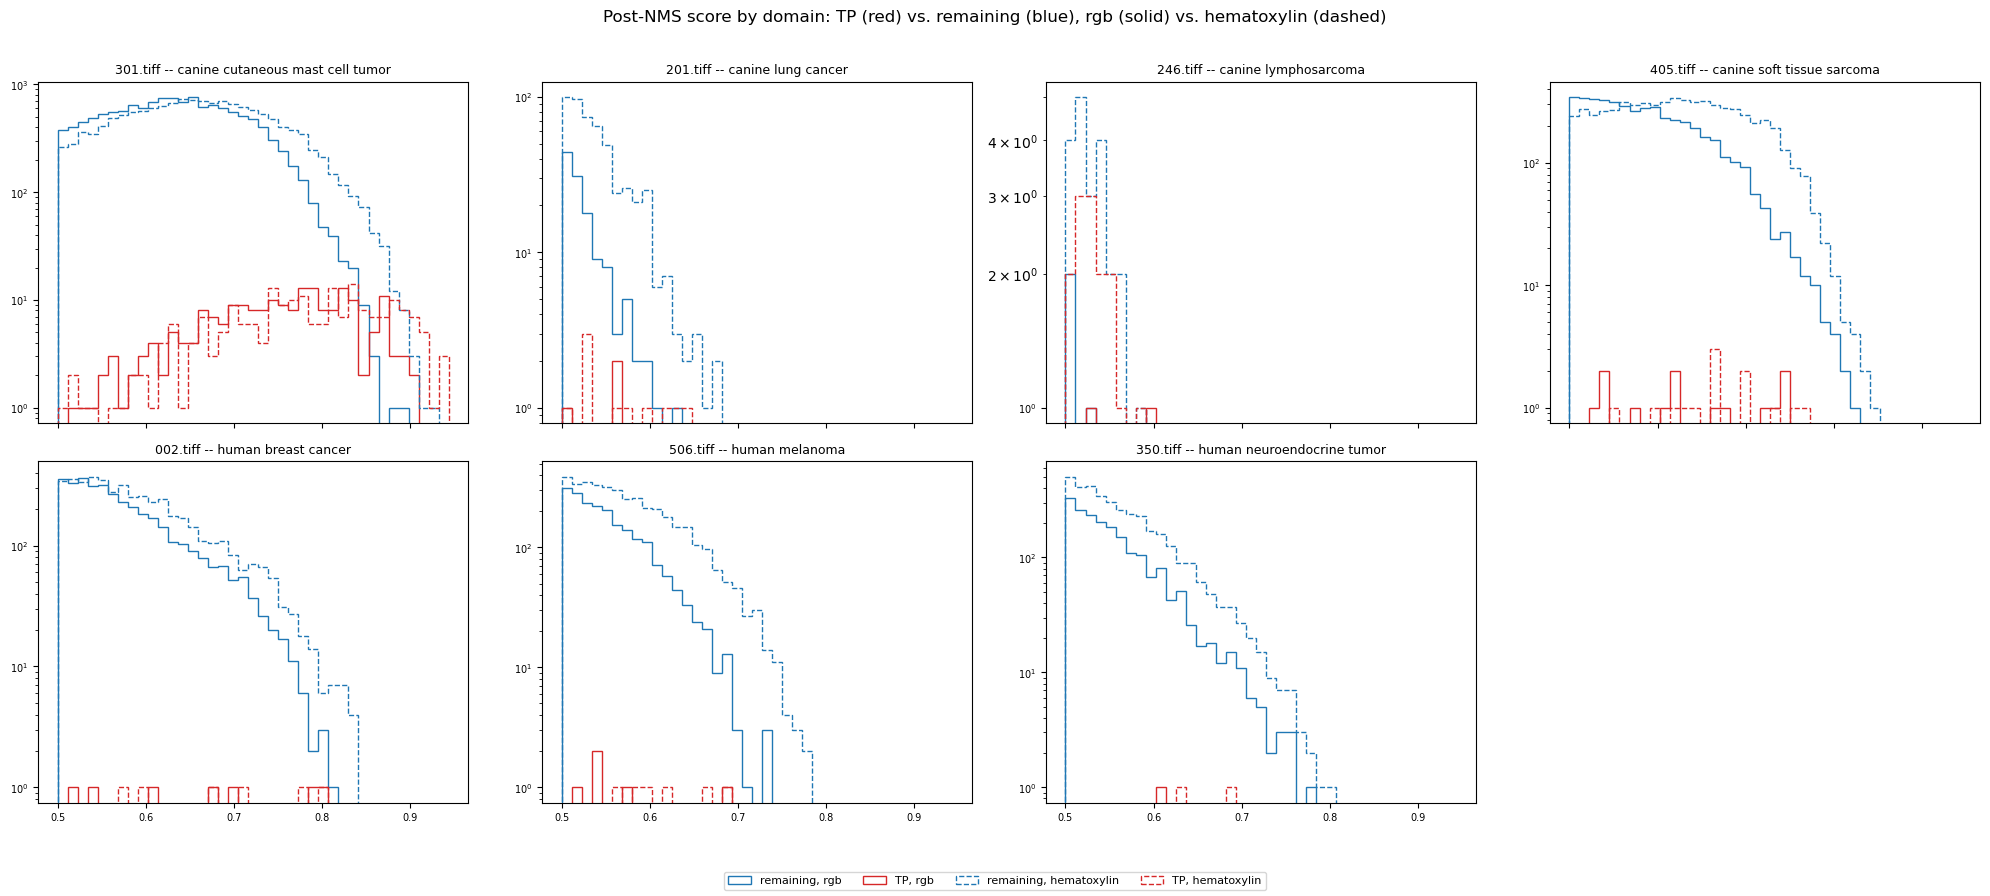

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharex=True)
file_names = selection['file_name'].tolist()

for ax, fn in zip(axes.ravel(), file_names):
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    sub = combined[combined.file_name == fn]
    for channel, ls in [('rgb', '-'), ('hematoxylin', '--')]:
        chsub = sub[sub.channel == channel]
        tp = chsub.loc[chsub.group2 == 'mitotic TP', 'score']
        rem = chsub.loc[chsub.group2 == 'remaining (FP)', 'score']
        if len(rem):
            ax.hist(rem, bins=bins, histtype='step', color='tab:blue', linestyle=ls,
                   label=f'remaining, {channel}', log=True)
        if len(tp):
            ax.hist(tp, bins=bins, histtype='step', color='tab:red', linestyle=ls,
                   label=f'TP, {channel}', log=True)
    ax.set_title(f'{fn} -- {tumor}', fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes.ravel()[len(file_names):]:
    ax.axis('off')
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=8)
fig.suptitle('Post-NMS score by domain: TP (red) vs. remaining (blue), rgb (solid) vs. hematoxylin (dashed)')
fig.tight_layout(rect=(0, 0.06, 1, 0.97))
plt.show()

## How to read this

- If the blue ("remaining") histogram has real mass at or above where the red ("TP")
  histogram sits, that's the tail-overlap problem from the design log made visible
  directly in the scores the matcher actually produces and NMS actually keeps -- not
  inferred from percentile tables.
- Compare the two channel panels in the pooled plots: a channel whose remaining-tail mass
  reaches further into the TP body is the one more likely to hand top-K to false
  candidates at a fixed score threshold, independent of `recall@K`, which only reads the
  budget-truncated top and can hide this.
- The three-way plot separates *why* the tail is heavy: if the blue "unannotated" mass
  dominates the tail, that's the base-rate/ordinary-nucleus problem the morphometric
  notebook's intensity feature targets; if the orange "look-alike" mass is what's closest
  to red, that's the harder mimicker problem neither intensity nor shape separated well
  there.